In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Read in file
df = pd.read_csv(
    "https://raw.githubusercontent.com/GloBIAS-BioimageAnalysts/Survey_2024/main/data/survey2024_headersandcommascleaned_recleaned.csv"
)

In [3]:
#Clean data
df.columns = df.columns.str.strip().str.replace('\n', ' ', regex=True)

In [4]:
df['What is your location'] = df['What is your location'].replace({
    'Australia/ Oceania': 'Australia/Oceania',
    'Near/ Middle East': 'Middle East'
})

In [5]:
#Summary of counts for each region
region_counts = df['What is your location'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']
region_counts

,Region,Count
0,Europe,178
1,North America,46
2,South America,28
3,Australia/Oceania,12
4,Asia,10
5,Middle East,8
6,Africa,6
7,Central America,1


In [6]:
df = df.rename(columns={
    'Are you currently in a permanent position': 'PermanentPosition'
})

In [7]:
region_col = 'What is your location'

region_counts = (
    df[region_col]
    .value_counts(dropna=False)
    .rename_axis('Region')
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

region_counts['Percent'] = 100 * region_counts['Count'] / region_counts['Count'].sum()
region_counts

,Region,Count,Percent
0,Europe,178,61.379310
1,North America,46,15.862069
2,South America,28,9.655172
3,Australia/Oceania,12,4.137931
4,Asia,10,3.448276
5,Middle East,8,2.758621
6,Africa,6,2.068966
7,Central America,1,0.344828
8,NaN,1,0.344828


In [8]:
summary_table = (
    df
    .dropna(subset=[region_col, 'PermanentPosition'])
    .groupby([region_col, 'PermanentPosition'])
    .size()
    .unstack(fill_value=0)
)

# Add percentages
summary_pct = summary_table.div(summary_table.sum(axis=1), axis=0) * 100

summary_table, summary_pct.round(1)

(PermanentPosition      No  Yes
 What is your location         
 Africa                  3    3
 Asia                    5    5
 Australia/Oceania       4    8
 Central America         0    1
 Europe                 82   96
 Middle East             1    7
 North America          11   35
 South America          10   18,
 PermanentPosition        No    Yes
 What is your location             
 Africa                 50.0   50.0
 Asia                   50.0   50.0
 Australia/Oceania      33.3   66.7
 Central America         0.0  100.0
 Europe                 46.1   53.9
 Middle East            12.5   87.5
 North America          23.9   76.1
 South America          35.7   64.3)

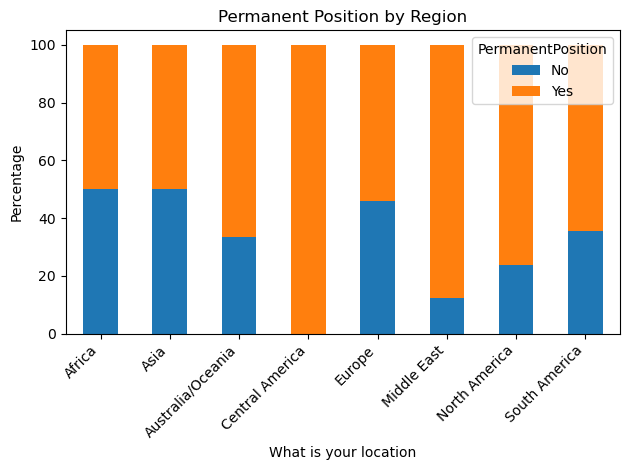

In [9]:
summary_pct.plot(
    kind='bar',
    stacked=True
)

plt.ylabel('Percentage')
plt.title('Permanent Position by Region')
plt.legend(title='PermanentPosition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

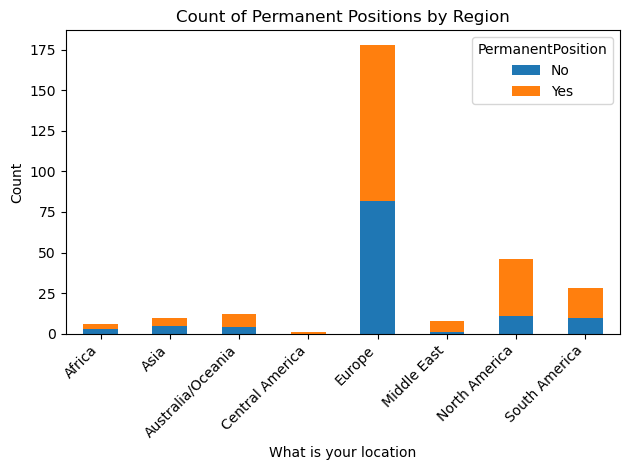

In [10]:
summary_table.plot(
    kind='bar',
    stacked=True
)

plt.ylabel('Count')
plt.title('Count of Permanent Positions by Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

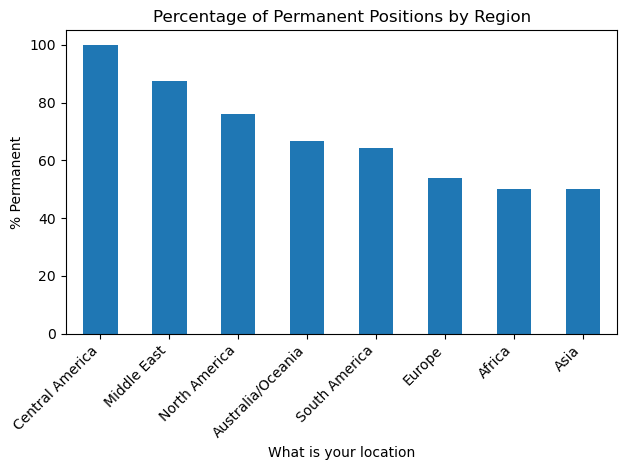

In [11]:
perm_only = summary_pct['Yes'].sort_values(ascending=False)

perm_only.plot(kind='bar')

plt.ylabel('% Permanent')
plt.title('Percentage of Permanent Positions by Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()